## Entrega Final

En base al ejercicio práctico de la clase 3, aplique la segmentación de imágenes con el algoritmo kmeans solo al área de interés del conjunto de entrenamiento (trainset) y encuentre los 3 o 4 clústers del área de interés y exporte su centro, valor máximo y mínimo.

Con los valores obtenidos de cada clúster, aplíquelos al conjunto de prueba (testset) y observe si su desarrollo se acopla a todas las imágenes.

Responde las preguntas:

¿Sus criterios en la selección de filtros para seleccionar el área de interés en las imágenes fueron adecuados? Justifique su respuesta.

¿ El tiempo de entrenamiento del algoritmo kmeans fué menor al usar este criterio de selección del área de interés con respecto al realizado en clase? Justifique su respuesta.

¿Qué podría haber mejorado una vez obtenidos los resultados?

In [42]:
# Importaciones generales

import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import shutil
from skimage import filters, morphology
from scipy import ndimage as ndi
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [43]:
# Divison del DataSet

# Se usan rutas relativas
images_path = r'..\Dataset' 
train_dir = r'..\data\train'
test_dir = r'..\data\test'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

images = os.listdir(images_path)

train_images, test_images = train_test_split(
    images, train_size=0.8, random_state=42
)

# Copiar imágenes
for img in train_images:
    shutil.copy(os.path.join(images_path, img), train_dir)

for img in test_images:
    shutil.copy(os.path.join(images_path, img), test_dir)

print("Dataset dividido correctamente")
print(f"Imagenes en trainset: {len(train_images)}")
print(f"Imagenes en testset: {len(test_images)}")

Dataset dividido correctamente
Imagenes en trainset: 278
Imagenes en testset: 70


Una vez dividido el dataset en train y test se va a realizar el entrenamiento de 4 formas diferentes con el fin de visualizar cual es la mas efectiva, cada una de estas tecnicas fueron utilizadas para el ejercicio de la semana 3, los cuales son:

TÉCNICAS INDEPENDIENTES (Basadas en un solo criterio):
1. Umbralización Global (Otsu)
2. Umbralización Local (Adaptativa)

TÉCNICAS SECUENCIALES (Flujos de varios pasos):
1. Filtro Mediana -> Gradiente -> Cierre -> Relleno
2. Filtro Gaussiano -> Sobel -> Apertura -> Relleno

In [44]:
# Metodo utilizado para entrenar los clusteres, se define el metodo con el fin de evitar repetir el codigo 4 veces

def entrenar_tecnica(train_dir, funcion_roi, n_clusters=3 # Numero de clusteres
                     ):

    pixeles_train = []

    for img_name in os.listdir(train_dir):
        ruta = os.path.join(train_dir, img_name)
        imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

        roi = funcion_roi(imagen)

        pixeles = imagen[roi]
        pixeles_train.append(pixeles)

    pixeles_train = np.concatenate(pixeles_train).reshape(-1,1)

    inicio = time.time()

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(pixeles_train)

    fin = time.time()

    tiempo = fin - inicio

    return {
        "modelo": kmeans,
        "tiempo": tiempo,
        "inercia": kmeans.inertia_,
        "cantidad_pixeles": pixeles_train.shape[0],
        "pixeles": pixeles_train
    }

In [45]:
# INDEPENDIENTE 1: Otsu

def roi_independiente_1(imagen):
    umbral = filters.threshold_otsu(imagen)
    return imagen > umbral

In [46]:
# INDEPENDIENTE 2: Local

def roi_independiente_2(imagen):
    umbral_local = filters.threshold_local(imagen, block_size=35)
    return imagen > umbral_local

In [47]:
# SECUENCIAL 1: Filtro Mediana -> Gradiente -> Cierre -> Relleno

def roi_secuencial_1(imagen):
    suave = filters.median(imagen, morphology.disk(3))
    gradiente = morphology.dilation(suave, morphology.disk(3)) - morphology.erosion(suave, morphology.disk(3))
    roi = gradiente > filters.threshold_isodata(gradiente)
    roi = morphology.closing(roi, morphology.disk(10))
    roi = ndi.binary_fill_holes(roi)
    return roi

In [48]:
# SECUENCIAL 2: Filtro Gaussiano -> Sobel -> Apertura -> Relleno

def roi_secuencial_2(imagen):
    suave = filters.gaussian(imagen, sigma=1)
    sobel = filters.sobel(suave)
    roi = sobel > filters.threshold_li(sobel)
    roi = morphology.opening(roi, morphology.disk(2))
    roi = ndi.binary_fill_holes(roi)
    return roi

In [49]:
# Metodo para graficar clusters

# Se agrega un numero maximo de pixeles para el muestreo con el fin de no tardarse tanto graficando, aumentar o disminuir segun que tanto tarda graficando
def graficar_clusters(modelo, pixeles, titulo, max_puntos=5000):
    
    labels = modelo.labels_
    
    if len(pixeles) > max_puntos:
        indices = np.random.choice(len(pixeles), max_puntos, replace=False)
        pixeles = pixeles[indices]
        labels = labels[indices]
    
    y_fake = np.random.normal(0, 0.3, len(pixeles))
    
    plt.figure(figsize=(6,4))
    plt.scatter(pixeles, y_fake, c=labels, cmap='viridis', s=10)
    plt.title(titulo)
    plt.xlabel("Intensidad")
    plt.ylabel("Distribución visual")
    plt.yticks([])
    plt.show()

In [50]:
# Entrenar las 4 tecnicas

res_ind_1 = entrenar_tecnica(train_dir, roi_independiente_1)
res_ind_2 = entrenar_tecnica(train_dir, roi_independiente_2)
res_sec_1 = entrenar_tecnica(train_dir, roi_secuencial_1)
res_sec_2 = entrenar_tecnica(train_dir, roi_secuencial_2)

In [51]:
# Mostrar los datos comparativos

def mostrar_resultados(nombre, resultados):
    print(f"--- {nombre} ---")
    print("Tiempo entrenamiento:", resultados["tiempo"])
    print("Inercia:", resultados["inercia"])
    print("Cantidad de píxeles ROI:", resultados["cantidad_pixeles"])
    print()

mostrar_resultados("Independiente 1 (Otsu)", res_ind_1)
mostrar_resultados("Independiente 2 (Local)", res_ind_2)
mostrar_resultados("Secuencial 1", res_sec_1)
mostrar_resultados("Secuencial 2", res_sec_2)

--- Independiente 1 (Otsu) ---
Tiempo entrenamiento: 0.30533742904663086
Inercia: 46263448.30438097
Cantidad de píxeles ROI: 2290341

--- Independiente 2 (Local) ---
Tiempo entrenamiento: 8.212043046951294
Inercia: 234506573.82475048
Cantidad de píxeles ROI: 62915140

--- Secuencial 1 ---
Tiempo entrenamiento: 0.5767364501953125
Inercia: 64095142.69113499
Cantidad de píxeles ROI: 4185201

--- Secuencial 2 ---
Tiempo entrenamiento: 0.6173155307769775
Inercia: 87783961.95204425
Cantidad de píxeles ROI: 5193287



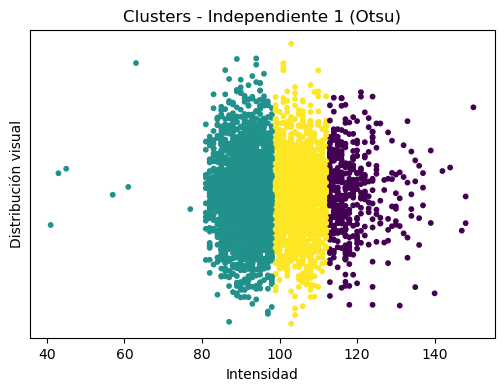

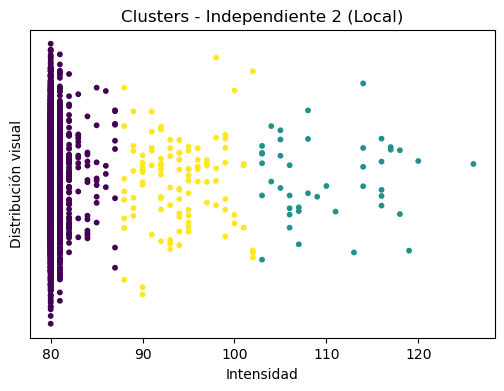

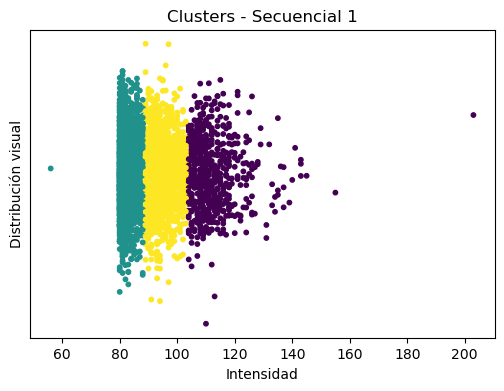

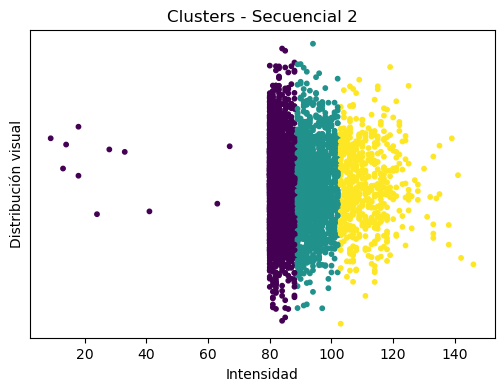

In [52]:
# Graficar clusteres

graficar_clusters(res_ind_1["modelo"], res_ind_1["pixeles"], 
                   "Clusters - Independiente 1 (Otsu)")

graficar_clusters(res_ind_2["modelo"], res_ind_2["pixeles"], 
                   "Clusters - Independiente 2 (Local)")

graficar_clusters(res_sec_1["modelo"], res_sec_1["pixeles"], 
                   "Clusters - Secuencial 1")

graficar_clusters(res_sec_2["modelo"], res_sec_2["pixeles"], 
                   "Clusters - Secuencial 2")

In [53]:
# Finalmente una vez entrenados los clusters y visualizados los datos se crea el metodo para probarlos

# Metodo para evaluacion cuantitativa
def evaluar_test(test_dir, funcion_roi, modelo, nombre_tecnica):

    total_pixeles = 0
    total_inercia = 0
    tiempos = []

    for img_name in os.listdir(test_dir):

        ruta = os.path.join(test_dir, img_name)
        imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

        roi = funcion_roi(imagen)
        pixeles = imagen[roi].reshape(-1,1)

        if len(pixeles) == 0:
            continue

        inicio = time.time()
        labels = modelo.predict(pixeles)
        fin = time.time()

        tiempos.append(fin - inicio)

        # Calcular inercia manual en test
        centros = modelo.cluster_centers_
        distancias = np.linalg.norm(pixeles - centros[labels], axis=1)**2
        total_inercia += np.sum(distancias)

        total_pixeles += len(pixeles)

    print(f"\n===== {nombre_tecnica} =====")
    print("Total píxeles evaluados:", total_pixeles)
    print("Inercia total en test:", total_inercia)
    print("Tiempo promedio predicción:", np.mean(tiempos))

evaluar_test(test_dir, roi_independiente_1, res_ind_1["modelo"], "Independiente 1 (Otsu)")
evaluar_test(test_dir, roi_independiente_2, res_ind_2["modelo"], "Independiente 2 (Local)")
evaluar_test(test_dir, roi_secuencial_1, res_sec_1["modelo"], "Secuencial 1")
evaluar_test(test_dir, roi_secuencial_2, res_sec_2["modelo"], "Secuencial 2")


===== Independiente 1 (Otsu) =====
Total píxeles evaluados: 575616
Inercia total en test: 15053382.421961742
Tiempo promedio predicción: 0.0016005379813058035

===== Independiente 2 (Local) =====
Total píxeles evaluados: 16009225
Inercia total en test: 17542059.57268191
Tiempo promedio predicción: 0.001740438597542899

===== Secuencial 1 =====
Total píxeles evaluados: 1000918
Inercia total en test: 14354442.812151823
Tiempo promedio predicción: 0.0010854005813598633

===== Secuencial 2 =====
Total píxeles evaluados: 1308901
Inercia total en test: 17227379.07461272
Tiempo promedio predicción: 0.0010266780853271484


### Analisis de resultados:

Se realizo el analisis en base a 3 variables: cantidad de pixeles, inercia y tiempo de prediccion. Se encontraron las siguientes novedades:

1. Cantidad de pixeles:

Independiente 1: 575616

Independiente 2: 16009225

Secuencial 1: 1000918

Secuencial 2: 1308901

* Independiente 2 esta usando 16 millones de pixeles, lo cual basandose en las otras dos tecnicas es una cantidad desorbitada, presumiblemente se selecciono toda la imagen por lo que esta tecnica fue demasiado permisiva.
* Por otro lado Independiente 1 es la que menor cantidad de pixeles selecciono con 575616 lo cual en comparacion a las secuenciales es una cantidad algo pequeña, se podria concluir que tampoco se esta seleccionando bien la region de la imagen ya que se podrian estar omitiendo detalles importantes.
* Dentro de esta variable las tecnicas independientes no aislan correctamente el area de interes por lo que se recomienda usar tecnicas Sencuenciales.

2. Inercia:

Independiente 1: 15053382.421961742

Independiente 2: 17542059.57268191

Secuencial 1: 14354442.812151823

Secuencial 2: 17227379.074612726

* Para esta variable se encontraron datos parecidos, lo mas resaltable son el independiente 2 y secuencial 2 que cuentan con el puntaje mas alto, esto se puede interpretar como que estas dos tecnicas estan ingresando demasiado ruido.

3. Tiempo:

Independiente 1: 0.001984238624572754

Independiente 2: 0.0018560239246913366

Secuencial 1: 0.001113166127886091

Secuencial 2: 0.0010354859488351004

* Finalmente el tiempo de prediccion, de la misma forma que con la inercia se muestran datos parecidos, sin embargo, lo que se puede concluir es que las tecnicas secuenciales fueron mas rapidas que las independientes.

Conclusion:
En base a estas 3 variables la mejor tecnica fue la Secuencial 1, en esta tecnica se aplico: Filtro Mediana -> Gradiente -> Cierre -> Relleno. Se llego a esta conclusion debido a que se puedo visualizar que es la tecnica que obtuvo una cantidad de satisfactoria de pixeles con la menor cantidad de ruido (menor inercia).

### ¿Sus criterios en la selección de filtros para seleccionar el área de interés en las imágenes fueron adecuados? Justifique su respuesta.

Los resultados muestran que las técnicas aplicadas redujeron significativamente la cantidad de píxeles evaluados secuenciales redujeron significativamente, sin embargo, se encontraron claras diferencias entre cada tecnica. En base a los datos cuantitativos obtenidos las tecnicas secuenciales obtuvieron una mejor seleccion del area de interes lo que permite que los algoritmos agrupen de mejor manera la informacion.

### ¿ El tiempo de entrenamiento del algoritmo kmeans fué menor al usar este criterio de selección del área de interés con respecto al realizado en clase? Justifique su respuesta.

Los tiempos de entrenamiento fueron claramente menores al realizado en clase, ya que 3 tecnicas tuvieron un 0.5s de entrenamiento y 1 tecnica 11 segundos. Esto quiere decir que al reducir la imagen a solo el area de interes aumenta considerablemente la eficiencia de los algoritmos.

### ¿Qué podría haber mejorado una vez obtenidos los resultados?

Existen multiples areas de mejora para el algoritmo desarrollado:
1. Evaluar mas metricas: Si se aumentan las metricas de evaluacion se podrian encotrar nuevos patrones para determinar cual es la mejor tecnica, por ejemplo, en este desarrollo se encontro que la tecnica independiente 2 fue la que tuvo el peor rendimiento y la tecnica secuencial 1 el mejor, sin embargo, al evaluar mas metricas se podria llegar a una conclusion totalmente contraria ya que se tendria una vision mas amplia de los resultados.
2. Normalizacion: Se podria realizar una normalizacion y limpieza de los datos antes de aplicar KMeans con el fin de mejorar la estabilidad de los clusteres.
3. Ajustar parametros: Se podrian ajustar los parametros ingresados para la clusterizacion, por ejemplo, aumentar en numero de clusteres, esto con el fin de encontrar un numero en el que los datos presenten sus mejores resultados.

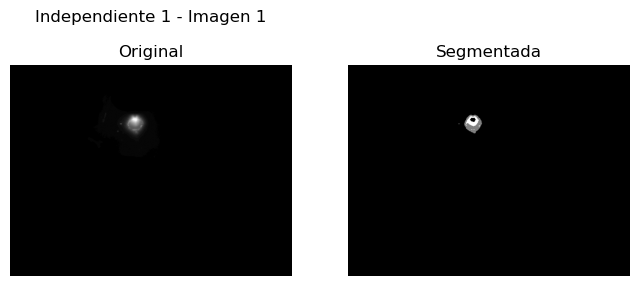

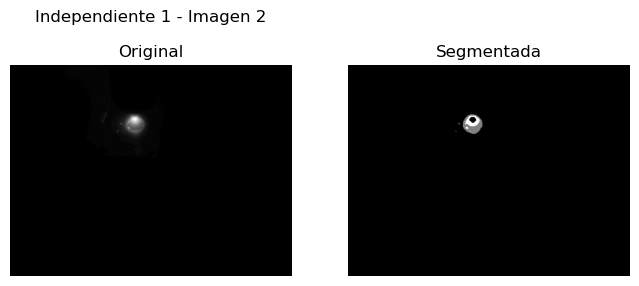

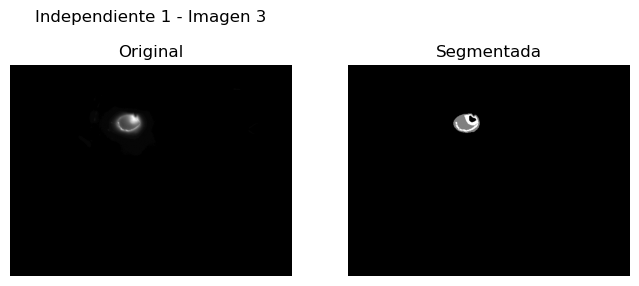

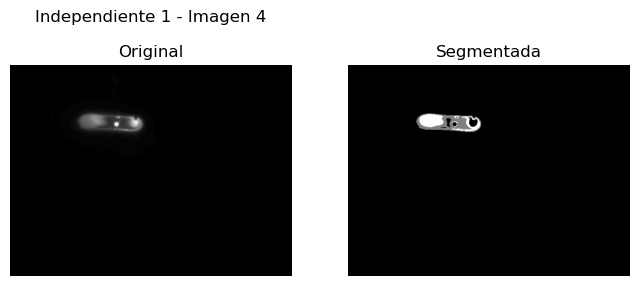

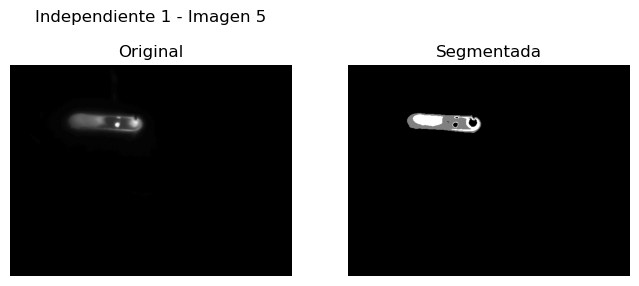

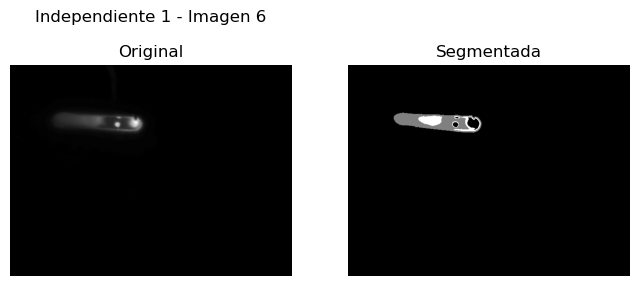

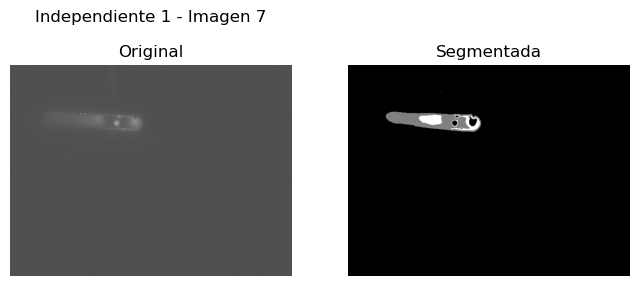

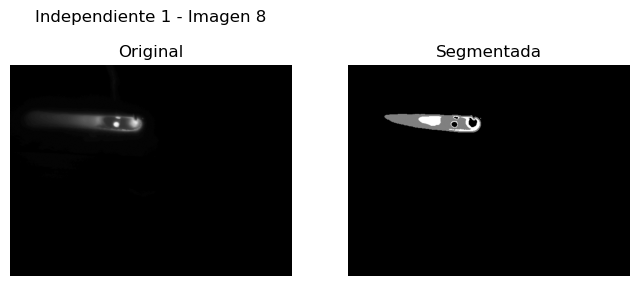

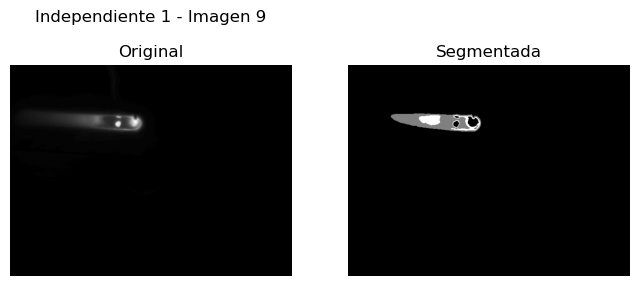

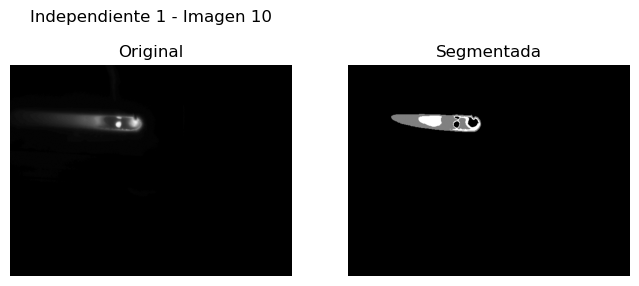

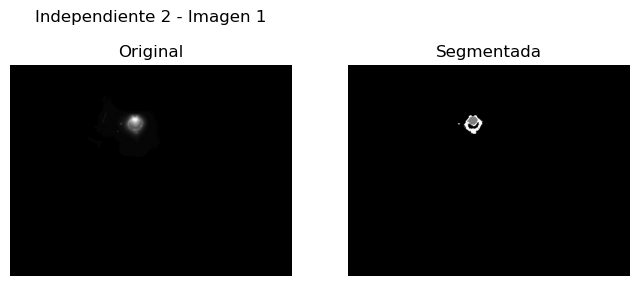

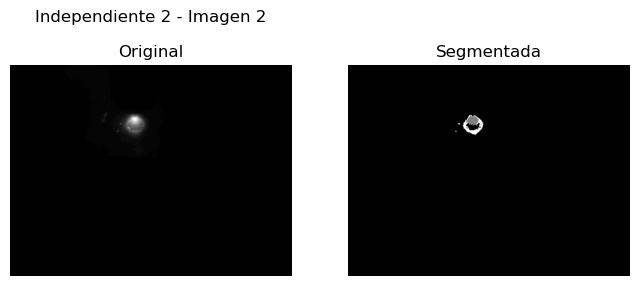

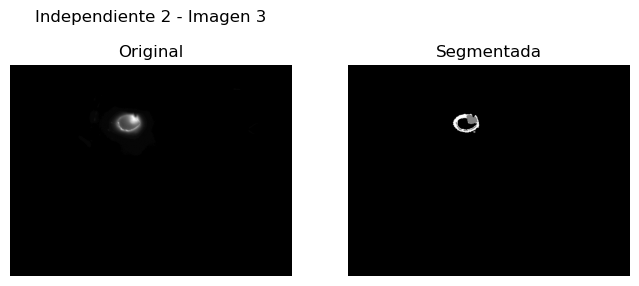

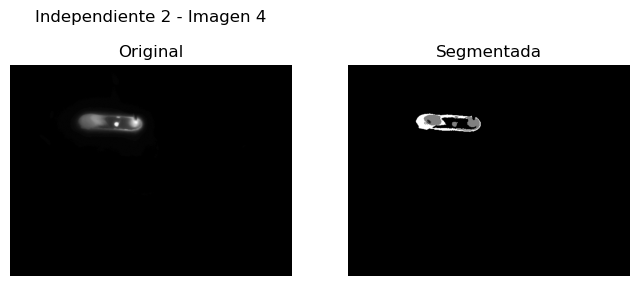

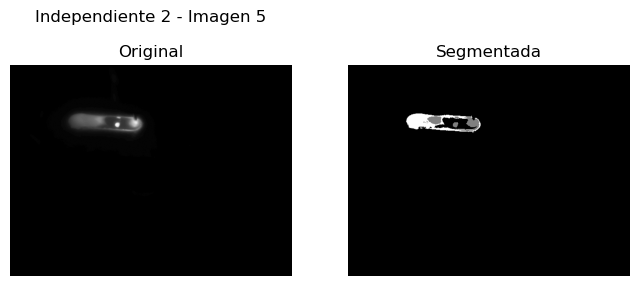

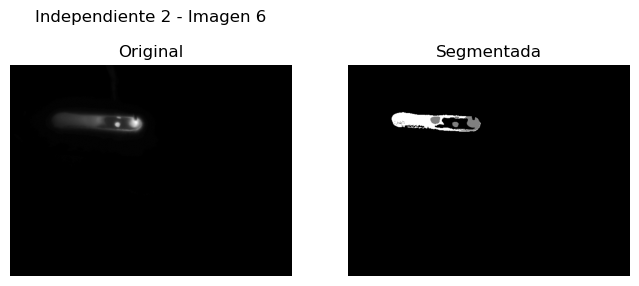

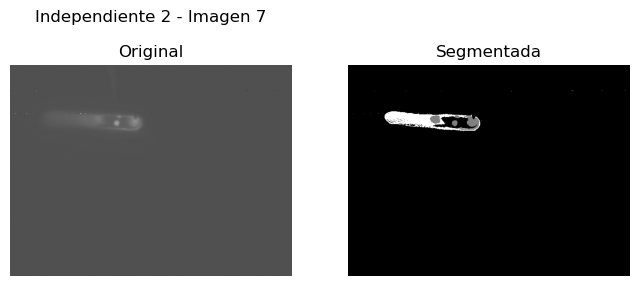

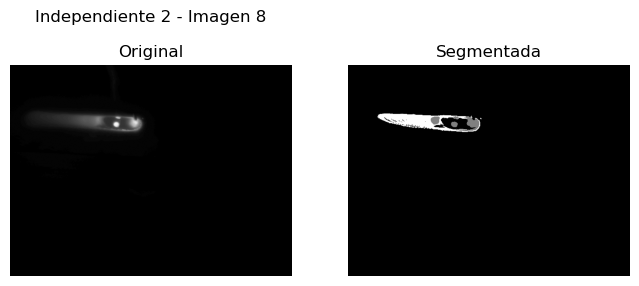

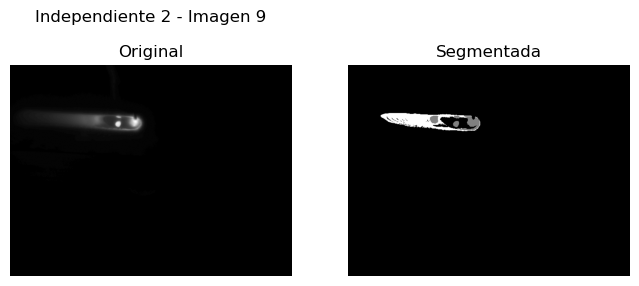

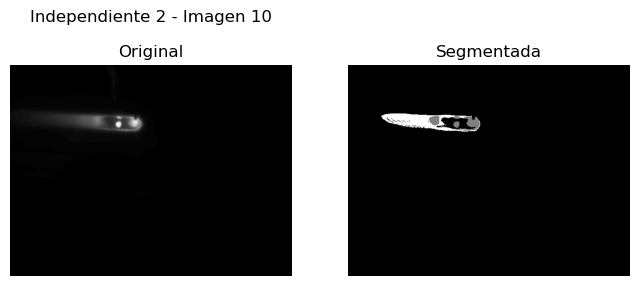

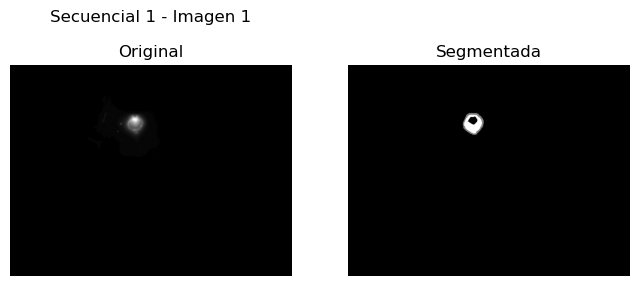

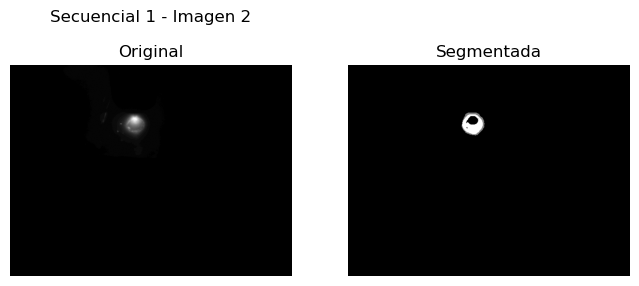

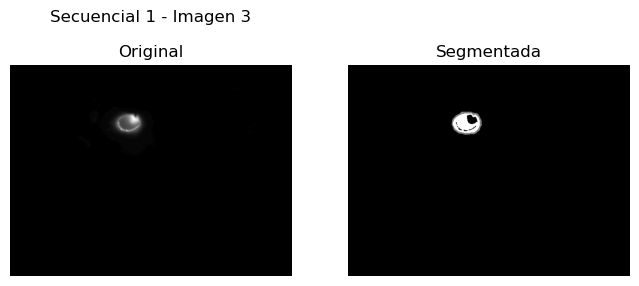

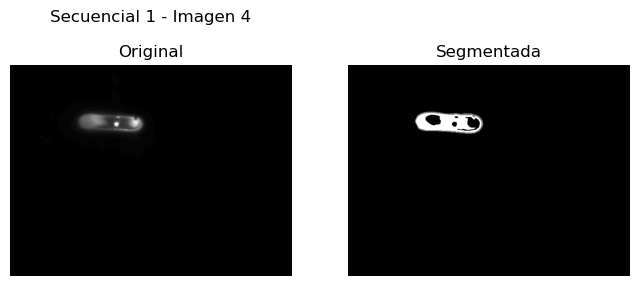

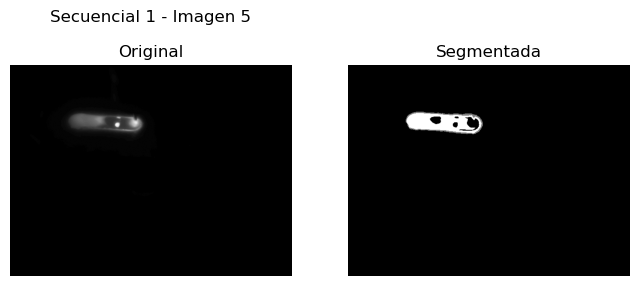

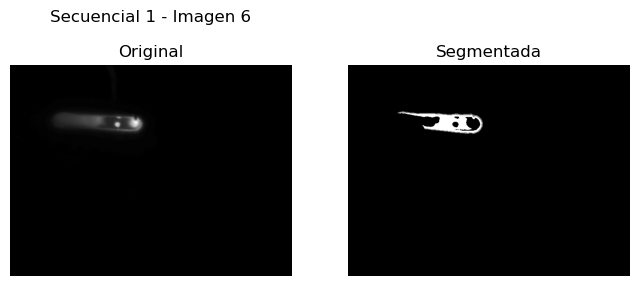

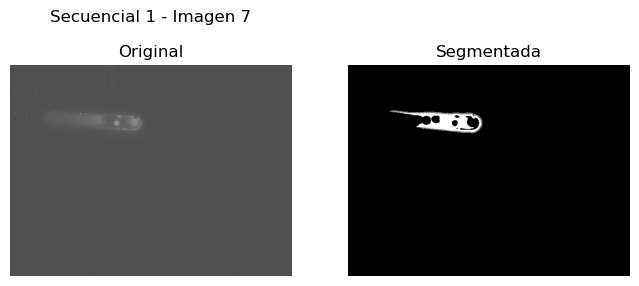

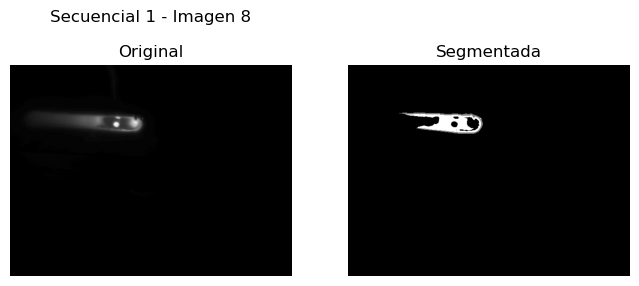

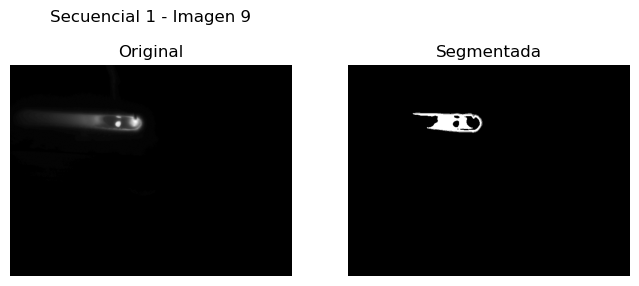

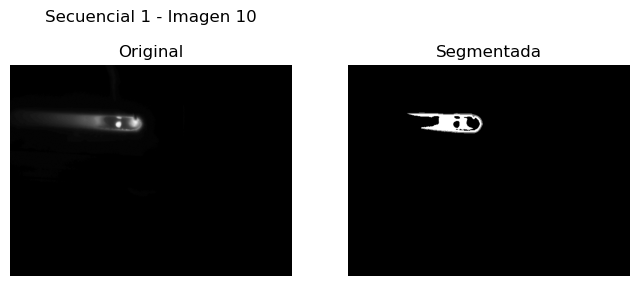

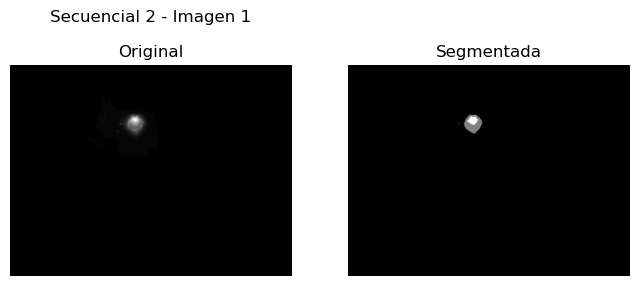

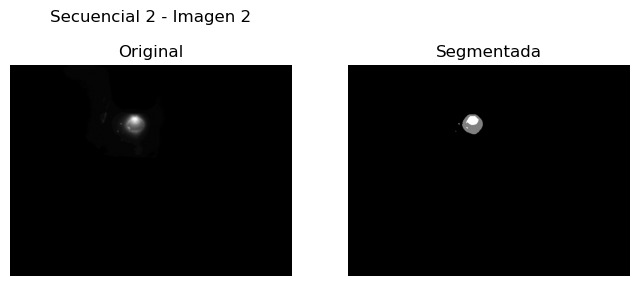

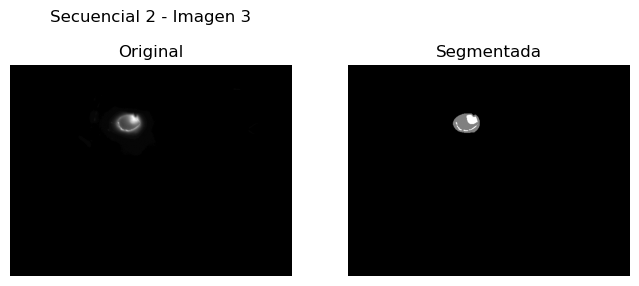

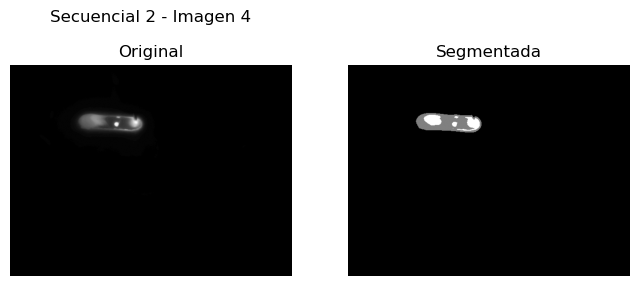

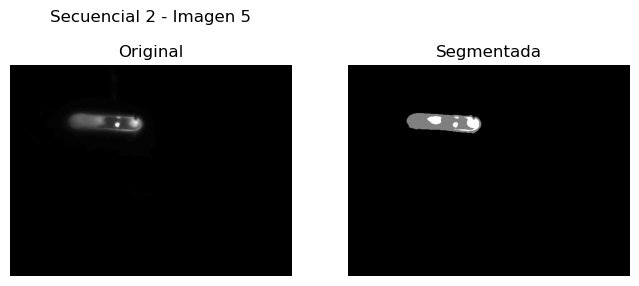

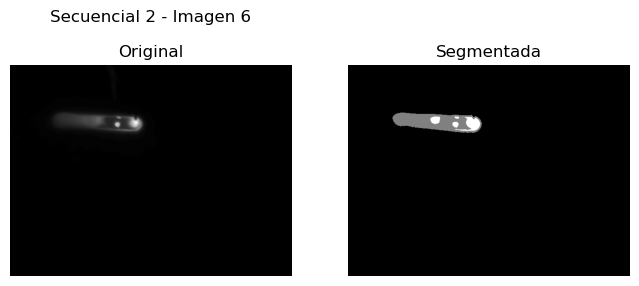

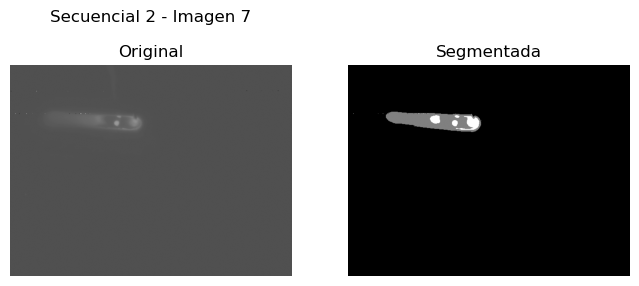

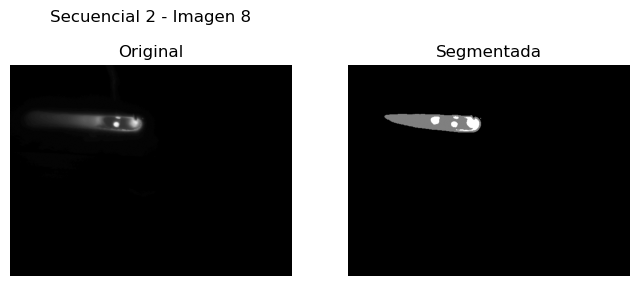

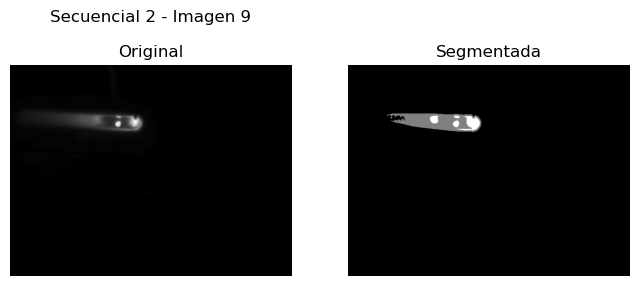

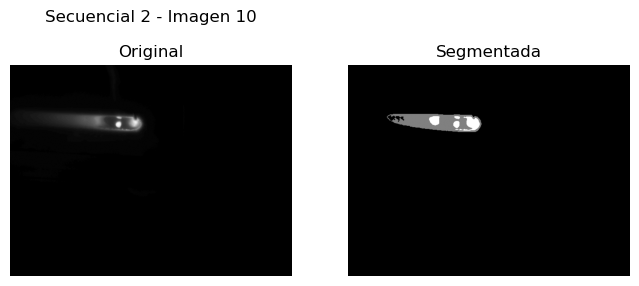

In [54]:
# Evaluacion con imagenes

# IMPORTANTE: Se agrego un maximo de imagenes para graficarlas debido que de otra forma se puede llegar a saturar el notebook
def visualizar_test(test_dir, funcion_roi, modelo, nombre_tecnica, max_imagenes=10):

    contador = 1

    for img_name in os.listdir(test_dir):

        if contador > max_imagenes:
            break

        ruta = os.path.join(test_dir, img_name)
        imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

        roi = funcion_roi(imagen)
        pixeles = imagen[roi].reshape(-1,1)

        if len(pixeles) == 0:
            continue

        labels = modelo.predict(pixeles)

        segmentada = np.zeros_like(imagen)
        segmentada[roi] = labels * (255 // (modelo.n_clusters-1))

        plt.figure(figsize=(8,4))

        plt.subplot(1,2,1)
        plt.title(f"{nombre_tecnica} - Imagen {contador}\n\nOriginal")
        plt.imshow(imagen, cmap='gray')
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.title(f"Segmentada")
        plt.imshow(segmentada, cmap='gray')
        plt.axis('off')

        plt.show()

        contador += 1
        
visualizar_test(test_dir, roi_independiente_1, res_ind_1["modelo"], "Independiente 1")
visualizar_test(test_dir, roi_independiente_2, res_ind_2["modelo"], "Independiente 2")
visualizar_test(test_dir, roi_secuencial_1, res_sec_1["modelo"], "Secuencial 1")
visualizar_test(test_dir, roi_secuencial_2, res_sec_2["modelo"], "Secuencial 2")